# Análisis Descriptivo

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### Carga de datos

In [126]:
df = pd.read_csv('WindSpeed.csv')
df.head()

,vs,gh,kw
0,-2.973167,-3.198333,-6.358000
1,14.278330,15.183330,10.151670
2,19.396670,15.240000,26.385000
3,7.312833,-7.018000,-5.733667
4,20.748330,8.880000,23.873330


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278 entries, 0 to 277
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vs      278 non-null    float64
 1   gh      278 non-null    float64
 2   kw      278 non-null    float64
dtypes: float64(3)
memory usage: 6.6 KB


### Estadísticas descriptivas

In [128]:
estadisticas = df.describe().T 
estadisticas.columns = ['Cantidad', 'Promedio', 'Desv. Estándar', 'Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo']
estadisticas.round(2)

,Cantidad,Promedio,Desv. Estándar,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
vs,278.0,16.98,13.61,-42.66,9.30,19.60,25.80,51.58
gh,278.0,12.74,13.33,-30.52,3.98,16.68,22.27,42.54
kw,278.0,14.03,17.24,-32.98,6.94,13.83,26.41,56.07


In [129]:
for col in df.columns:
    rango = df[col].max() - df[col].min()
    print(f'\nSensor: {col.upper()}')
    print(f'  Rango     : {rango:.4f}')
    print(f'  Varianza  : {df[col].var():.4f}')
    print(f'  Asimetría : {df[col].skew():.4f}')
    print(f'  Curtosis  : {df[col].kurt():.4f}')


Sensor: VS
  Rango     : 94.2483
  Varianza  : 185.3073
  Asimetría : -0.8585
  Curtosis  : 1.4547

Sensor: GH
  Rango     : 73.0500
  Varianza  : 177.7792
  Asimetría : -0.6995
  Curtosis  : -0.3487

Sensor: KW
  Rango     : 89.0500
  Varianza  : 297.1668
  Asimetría : -0.4141
  Curtosis  : 0.0528


### Coeficiente de Variación

In [130]:
cv = (df.std() / df.mean() * 100).round(2)

for sensor, valor in cv.items():
    nivel = 'Alta' if valor > 100 else 'Moderada-Alta' if valor > 50 else 'Moderada'
    print(f'  Sensor {sensor.upper():3s}: {valor:>7.2f}%  → Variabilidad {nivel}')

  Sensor VS :   80.17%  → Variabilidad Moderada-Alta
  Sensor GH :  104.65%  → Variabilidad Alta
  Sensor KW :  122.85%  → Variabilidad Alta


### Valores nulos

In [131]:
nulos = df.isnull().sum()
print(nulos)


vs    0
gh    0
kw    0
dtype: int64


### Histograma

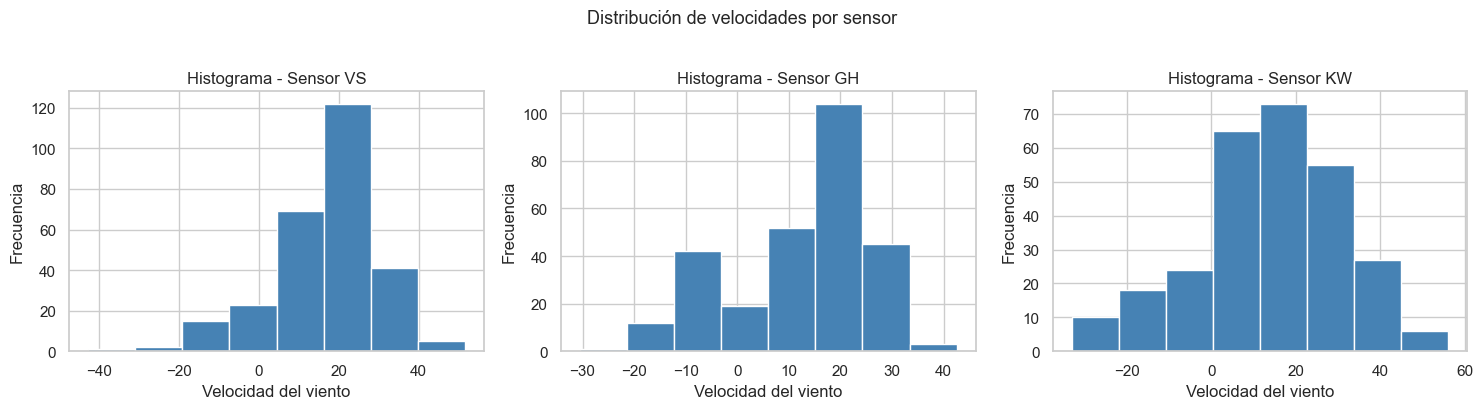

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, df.columns):
    ax.hist(df[col], bins=8, color='steelblue', edgecolor='white')
    ax.set_title(f'Histograma - Sensor {col.upper()}')
    ax.set_xlabel('Velocidad del viento')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de velocidades por sensor', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Boxplots

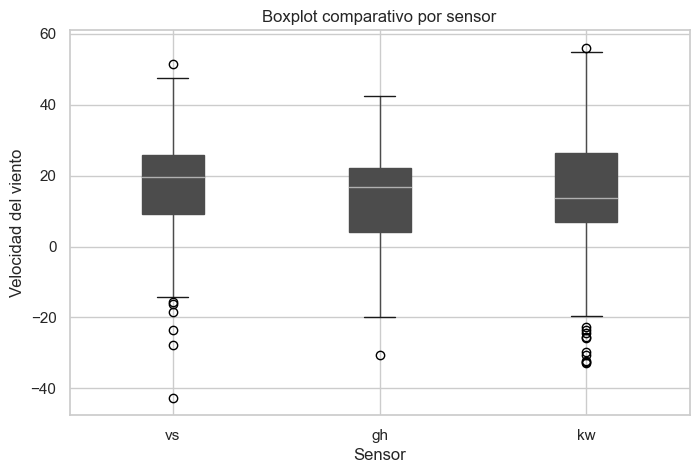

In [133]:
plt.figure(figsize=(8, 5))
df.boxplot(column=list(df.columns), patch_artist=True)
plt.title('Boxplot comparativo por sensor')
plt.xlabel('Sensor')
plt.ylabel('Velocidad del viento')
plt.show()

### Línea de tiempo

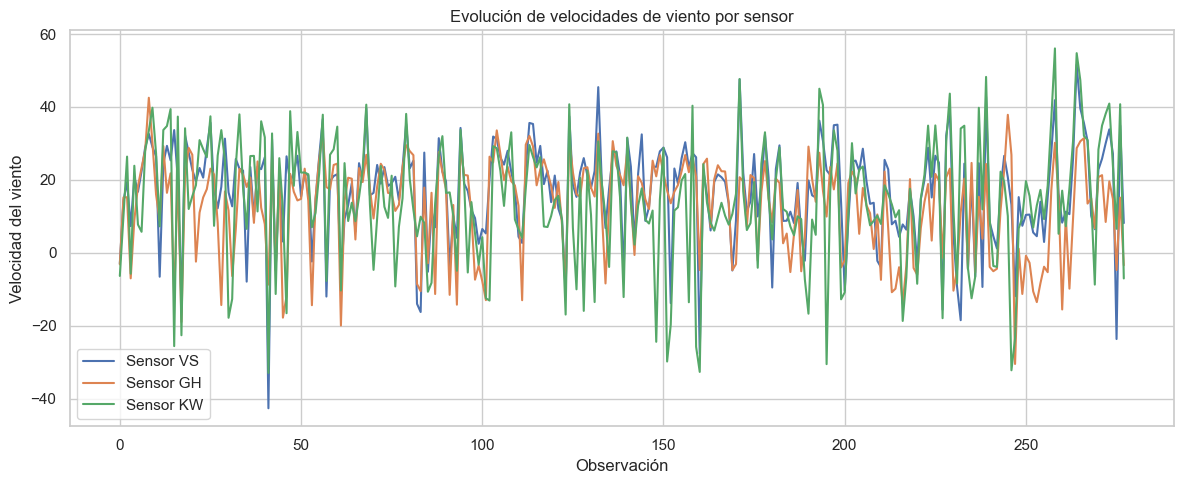

In [134]:
plt.figure(figsize=(12, 5))

for col in df.columns:
    plt.plot(df.index, df[col], label=f'Sensor {col.upper()}')

plt.title('Evolución de velocidades de viento por sensor')
plt.xlabel('Observación')
plt.ylabel('Velocidad del viento')
plt.legend()
plt.tight_layout()
plt.show()

### Correlación y Covarianza

In [135]:
# Matriz de covarianza
df.cov().round(4)

,vs,gh,kw
vs,185.3073,126.9589,148.1797
gh,126.9589,177.7792,110.6200
kw,148.1797,110.6200,297.1668


In [136]:
# Matriz de correlación
df.corr().round(4)

,vs,gh,kw
vs,1.0000,0.6995,0.6315
gh,0.6995,1.0000,0.4813
kw,0.6315,0.4813,1.0000


### Correlación de Spearman

In [137]:
spearman = df.corr(method='spearman').round(4)
spearman

,vs,gh,kw
vs,1.0000,0.7331,0.6841
gh,0.7331,1.0000,0.4940
kw,0.6841,0.4940,1.0000


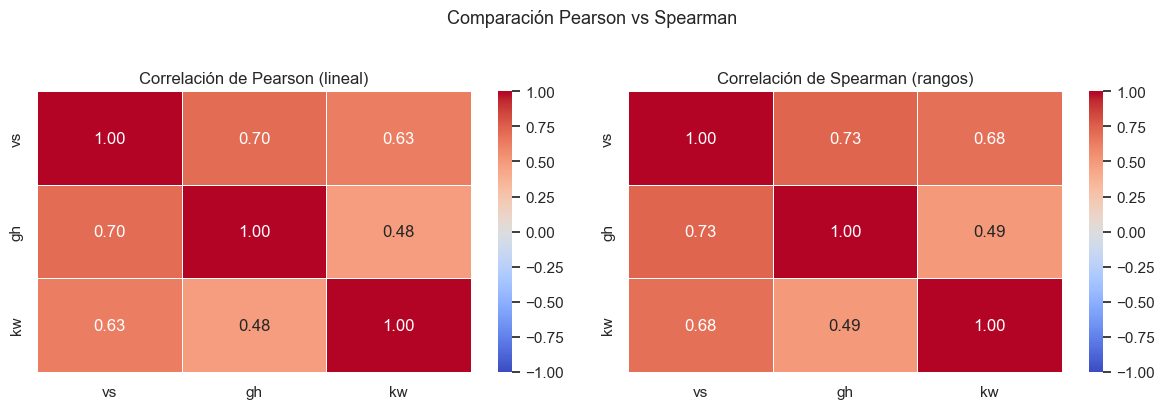

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, method, title in zip(axes,
                              ['pearson', 'spearman'],
                              ['Pearson (lineal)', 'Spearman (rangos)']):
    sns.heatmap(df.corr(method=method), annot=True, fmt='.2f',
                cmap='coolwarm', vmin=-1, vmax=1,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Correlación de {title}')

plt.suptitle('Comparación Pearson vs Spearman', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Gráficos de Dispersión

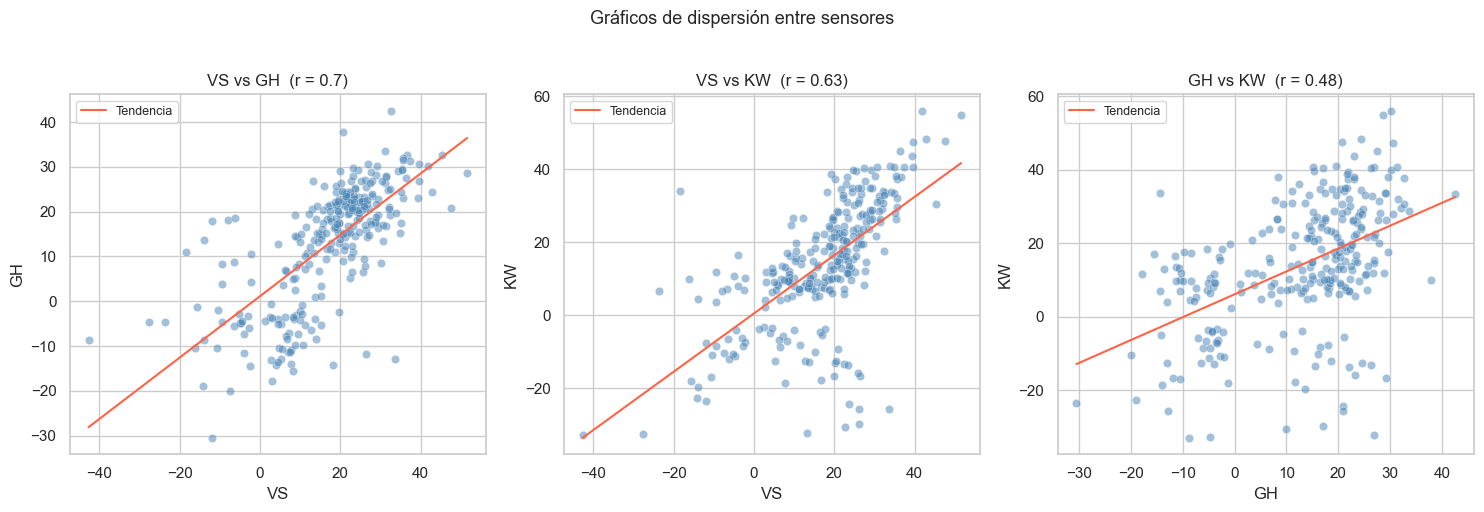

In [139]:
pares = [('vs', 'gh'), ('vs', 'kw'), ('gh', 'kw')]
correlaciones = {('vs', 'gh'): 0.70, ('vs', 'kw'): 0.63, ('gh', 'kw'): 0.48}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (x, y) in zip(axes, pares):
    ax.scatter(df[x], df[y], alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.4)
    # Línea de tendencia
    m, b = np.polyfit(df[x], df[y], 1)
    x_line = [df[x].min(), df[x].max()]
    ax.plot(x_line, [m * xi + b for xi in x_line], color='tomato', linewidth=1.5, label='Tendencia')
    r = correlaciones[(x, y)]
    ax.set_title(f'{x.upper()} vs {y.upper()}  (r = {r})')
    ax.set_xlabel(x.upper())
    ax.set_ylabel(y.upper())
    ax.legend(fontsize=9)

plt.suptitle('Gráficos de dispersión entre sensores', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()